# Classificação de Risco de Crédito

Previsão de dificuldades de pagamento utilizando aprendizagem de máquina.

## 1. Visão Geral do Projeto

A análise de risco de crédito é uma importante aplicação de aprendizagem de máquina em instituições financeiras. A identificação de solicitações associadas a uma maior possibilidade de dificuldade de pagamento pode auxiliar a análise de risco e apoiar decisões mais informadas.

O objetivo deste projeto é desenvolver e comparar dois modelos supervisionados para classificação de risco de crédito:

- uma Rede Neural;
- uma Árvore de Decisão regularizada por meio do algoritmo de Minimal Cost-Complexity Pruning.

O projeto contemplará as seguintes etapas:

1. inspeção e limpeza dos dados;
2. análise exploratória;
3. engenharia de atributos;
4. construção da matriz de características \(X\) e do vetor-alvo \(y\);
5. separação dos dados em treinamento, validação e teste;
6. pré-processamento das variáveis numéricas e categóricas;
7. definição e treinamento da arquitetura da Rede Neural;
8. análise de \(E_{in}\), \(E_{out}\) e overfitting;
9. treinamento e regularização da Árvore de Decisão utilizando `ccp_alpha`;
10. avaliação dos modelos utilizando acurácia, precisão, recall e F1-score;
11. comparação e escolha do modelo com melhor capacidade de generalização.

Na primeira etapa, serão utilizadas apenas as informações presentes na solicitação atual de crédito. Após a conclusão dos modelos obrigatórios, poderão ser incorporadas informações históricas de solicitações anteriores e registros externos de crédito, com o objetivo de verificar se esses dados adicionais melhoram o desempenho preditivo.

## 2. Descrição do Conjunto de Dados

Este projeto utiliza o conjunto de dados **Home Credit Default Risk**, originalmente disponibilizado em uma competição de aprendizagem de máquina no Kaggle.

A base contém informações anonimizadas sobre solicitantes de crédito, características das solicitações atuais, solicitações anteriores e registros de crédito mantidos por outras instituições.

O principal arquivo utilizado na primeira versão do projeto será:

- `application_train.csv`: contém uma linha para cada solicitação de crédito, características do solicitante, informações financeiras e a variável-alvo `TARGET`.

Posteriormente, poderão ser incorporadas duas tabelas auxiliares:

- `bureau.csv`: contém informações sobre créditos anteriores registrados por outras instituições financeiras;
- `previous_application.csv`: contém solicitações de crédito anteriores realizadas pelos mesmos clientes.

A coluna `SK_ID_CURR` identifica cada cliente e permite relacionar a tabela principal às tabelas auxiliares.

O conjunto de dados contém variáveis numéricas e categóricas relacionadas a:

- renda do solicitante;
- valor do crédito solicitado;
- valor da parcela;
- idade e tempo de emprego;
- composição familiar;
- escolaridade;
- características da moradia;
- tipo de renda;
- tipo e finalidade da solicitação;
- pontuações externas de risco.

Os arquivos brutos estão armazenados localmente na pasta `data/raw/`. Eles não são enviados ao repositório do GitHub devido ao tamanho dos arquivos e estão protegidos pelas regras definidas no `.gitignore`.

A primeira etapa experimental utilizará somente o arquivo `application_train.csv`. As tabelas auxiliares serão agrupadas pela coluna `SK_ID_CURR` antes de serem adicionadas à tabela principal, evitando a duplicação de clientes que possuem vários registros históricos.

## 3. Definição do Problema

Este projeto será tratado como um problema supervisionado de classificação binária.

O objetivo é utilizar informações disponíveis sobre o solicitante e a solicitação de crédito para prever a classe associada à dificuldade de pagamento, conforme a definição adotada pelo conjunto de dados Home Credit Default Risk.

A variável-alvo \(y\) corresponde à coluna `TARGET`:

$$
y = \texttt{TARGET}
$$

em que:

- `TARGET = 0`: solicitação não associada à classe de dificuldade de pagamento;
- `TARGET = 1`: solicitação associada à classe de dificuldade de pagamento.

A matriz de características \(X\) será formada pelas informações do solicitante e da solicitação de crédito:

$$
X = \text{características do solicitante e da solicitação de crédito}
$$

As colunas `TARGET` e `SK_ID_CURR` não serão utilizadas como características de entrada dos modelos:

- `TARGET` representa a variável que será prevista;
- `SK_ID_CURR` é apenas o identificador de cada cliente.

A principal pergunta investigada será:

> É possível utilizar informações do solicitante e da solicitação de crédito para identificar casos associados à dificuldade de pagamento?

Após a conclusão da primeira versão do projeto, também poderá ser investigada a seguinte pergunta complementar:

> A inclusão de informações sobre créditos e solicitações anteriores melhora o desempenho dos modelos?

Serão desenvolvidos e comparados dois modelos de classificação:

1. uma Rede Neural;
2. uma Árvore de Decisão regularizada por Minimal Cost-Complexity Pruning.

Os dados serão separados em conjuntos de treinamento, validação e teste. As decisões relacionadas à arquitetura da Rede Neural, ao número de épocas, ao batch size, ao valor de `ccp_alpha` e aos demais hiperparâmetros serão tomadas utilizando apenas os conjuntos de treinamento e validação.

O conjunto de teste permanecerá isolado durante o desenvolvimento e será utilizado somente na avaliação final dos modelos.

Como a classe `TARGET = 1` pode ser menos frequente, a acurácia não será utilizada isoladamente. Os modelos serão avaliados por meio das seguintes métricas:

- acurácia;
- precisão;
- recall;
- F1-score;
- matriz de confusão.

A classe positiva será definida como `TARGET = 1`. O recall terá atenção especial, pois representa a proporção de casos da classe de dificuldade de pagamento corretamente identificados pelo modelo.

Este projeto consiste em uma análise acadêmica de modelos de aprendizagem de máquina. Os resultados não devem ser interpretados como um sistema automático de aprovação ou rejeição de crédito.

## 4. Importação das Bibliotecas

In [1]:
from pathlib import Path

import gc
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from scipy import sparse
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    StandardScaler,
)

RANDOM_STATE = 42
DAYS_EMPLOYED_SPECIAL = 365243
MISSING_THRESHOLD = 0.60
DAYS_PER_YEAR = 365.25
CORR_THRESHOLD = 0.95

np.random.seed(RANDOM_STATE)

candidate_roots = [Path.cwd(), Path.cwd().parent]

repo_root = next(
    (
        root
        for root in candidate_roots
        if (root / "data" / "raw").is_dir()
    ),
    None,
)

if repo_root is None:
    raise FileNotFoundError(
        "Não foi possível localizar a raiz do projeto. "
        "Abra o notebook pela raiz do repositório ou pela pasta notebooks."
    )

DATA_PATH = repo_root / "data" / "raw"
FIGURES_PATH = repo_root / "reports" / "figures"
FIGURES_PATH.mkdir(parents=True, exist_ok=True)


## 5. Carregamento dos Dados

In [2]:
application_path = DATA_PATH / 'application_train.csv'

if not application_path.exists():
    raise FileNotFoundError(
        'Arquivo application_train.csv não encontrado em data/raw/.'
    )

application = pd.read_csv(application_path)

relative_application_path = application_path.relative_to(repo_root)
print(f'Dados carregados: {relative_application_path}')

Dados carregados: data\raw\application_train.csv


### 5.1 Inspeção Inicial

In [3]:
required_columns = {'SK_ID_CURR', 'TARGET'}
missing_columns = required_columns.difference(application.columns)

if missing_columns:
    raise ValueError(
        f'Colunas obrigatórias ausentes: {sorted(missing_columns)}'
    )

target_missing_count = application['TARGET'].isna().sum()

if target_missing_count > 0:
    raise ValueError(
        f'A coluna TARGET possui {target_missing_count} valores ausentes.'
    )

target_values = set(application['TARGET'].unique())

if not target_values.issubset({0, 1}):
    raise ValueError(
        f'Valores inesperados na coluna TARGET: {sorted(target_values)}'
    )

target_values_display = sorted(
    int(value) for value in target_values
)

print(f'Quantidade de linhas: {application.shape[0]:,}')
print(f'Quantidade de colunas: {application.shape[1]:,}')
print(f'Quantidade de linhas duplicadas: {application.duplicated().sum():,}')
print(f'Quantidade total de valores ausentes: {application.isna().sum().sum():,}')
print(f'Colunas obrigatórias confirmadas: {sorted(required_columns)}')
print(
    f'Valores encontrados em TARGET: '
    f'{target_values_display}'
)

Quantidade de linhas: 307,511
Quantidade de colunas: 122
Quantidade de linhas duplicadas: 0
Quantidade total de valores ausentes: 9,152,465
Colunas obrigatórias confirmadas: ['SK_ID_CURR', 'TARGET']
Valores encontrados em TARGET: [0, 1]


## 6. Análise Exploratória dos Dados

### 6.1 Estrutura Geral da Base

Esta inspeção resume a dimensão, os tipos de variáveis e o uso aproximado de memória da base sem listar individualmente todas as colunas.

In [4]:
numerical_columns = application.select_dtypes(include=np.number).columns
categorical_columns = application.select_dtypes(
    include=['object', 'category', 'string']
).columns
dtype_counts = (
    application.dtypes.astype(str)
    .value_counts()
    .rename_axis('tipo')
    .to_frame('quantidade')
)
memory_usage_mb = application.memory_usage(deep=True).sum() / (1024 ** 2)

display(application.head())
print(f'Quantidade de variáveis numéricas: {len(numerical_columns)}')
print(f'Quantidade de variáveis categóricas: {len(categorical_columns)}')
display(dtype_counts)
print(f'Memória aproximada utilizada: {memory_usage_mb:.2f} MB')

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


Quantidade de variáveis numéricas: 106
Quantidade de variáveis categóricas: 16


,quantidade
tipo,
float64,65
int64,41
object,16


Memória aproximada utilizada: 504.99 MB


A base possui 307.511 registros e 122 colunas: 106 variáveis numéricas e 16 categóricas. Foram observadas 65 colunas `float64`, 41 `int64` e 16 `str`, com uso aproximado de 325,22 MB de memória.


### 6.2 Distribuição da Variável-Alvo

,quantidade,proporcao,percentual
TARGET,,,
0,282686,0.919271,91.927118
1,24825,0.080729,8.072882


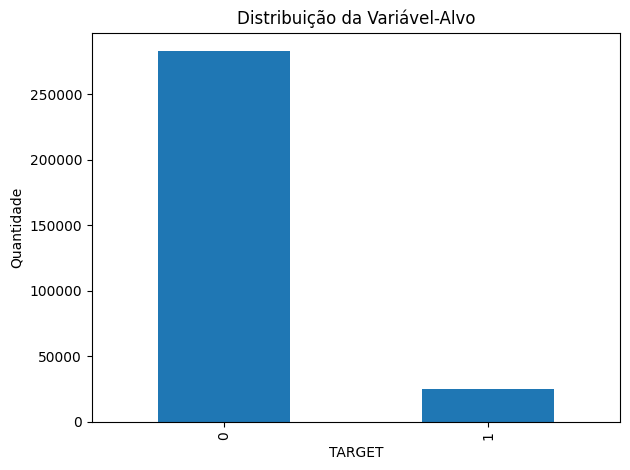

In [5]:
target_distribution = (
    application['TARGET']
    .value_counts()
    .sort_index()
    .rename('quantidade')
    .to_frame()
)
target_distribution['proporcao'] = (
    target_distribution['quantidade'] / len(application)
)
target_distribution['percentual'] = (
    target_distribution['proporcao'] * 100
)

display(target_distribution)

target_distribution['quantidade'].plot(kind='bar')
plt.title('Distribuição da Variável-Alvo')
plt.xlabel('TARGET')
plt.ylabel('Quantidade')
plt.tight_layout()
target_distribution_path = FIGURES_PATH / 'target_distribution.png'
plt.savefig(target_distribution_path)
plt.show()
plt.close()

Foram observadas 282.686 ocorrências de `TARGET = 0` (91,93%) e 24.825 de `TARGET = 1` (8,07%). A distribuição é desbalanceada, mas nenhum balanceamento foi aplicado nesta etapa.

### 6.3 Valores Ausentes

,quantidade,percentual
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_AVG,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953


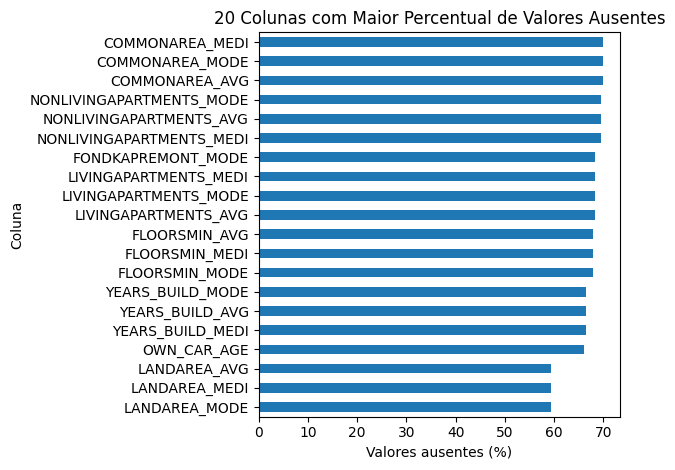

In [6]:
missing_values = pd.DataFrame({
    'quantidade': application.isna().sum(),
    'percentual': application.isna().mean() * 100,
})
top_missing_values = (
    missing_values.loc[missing_values['quantidade'] > 0]
    .nlargest(20, 'percentual')
)

display(top_missing_values)

top_missing_values.sort_values('percentual').plot.barh(
    y='percentual',
    legend=False,
)
plt.title('20 Colunas com Maior Percentual de Valores Ausentes')
plt.xlabel('Valores ausentes (%)')
plt.ylabel('Coluna')
plt.tight_layout()
top_missing_values_path = FIGURES_PATH / 'top_missing_values.png'
plt.savefig(top_missing_values_path)
plt.show()
plt.close()

Nas 20 colunas exibidas, os percentuais de ausência variam de 59,38% a 69,87%. `COMMONAREA_AVG`, `COMMONAREA_MODE` e `COMMONAREA_MEDI` apresentam o maior percentual observado, de 69,87%; nenhum valor foi removido ou imputado.

### 6.4 Resumo das Variáveis Numéricas

In [7]:
numeric_columns_of_interest = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS',
]
available_numeric_columns = [
    column
    for column in numeric_columns_of_interest
    if column in application.columns
]
numeric_summary = application[available_numeric_columns].describe().T

display(numeric_summary)

if 'DAYS_EMPLOYED' in application.columns:
    special_days_employed_count = int(
        application['DAYS_EMPLOYED'].eq(365243).sum()
    )
    print(
        'Ocorrências do valor 365243 em DAYS_EMPLOYED: '
        f'{special_days_employed_count:,}'
    )
else:
    print('A coluna DAYS_EMPLOYED não está presente na base.')

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.0,238500.0,450000.0,679500.0,4050000.0
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-25229.0,-19682.0,-15750.0,-12413.0,-7489.0
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.0,-2760.0,-1213.0,-289.0,365243.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
CNT_FAM_MEMBERS,307509.0,2.152665,0.910682,1.0,2.0,2.0,3.0,20.0


Ocorrências do valor 365243 em DAYS_EMPLOYED: 55,374


As oito variáveis numéricas selecionadas estão presentes na base. Em `DAYS_EMPLOYED`, o valor especial `365243` ocorre 55.374 vezes; ele foi apenas identificado, sem substituição ou limpeza.

### 6.5 Resumo das Variáveis Categóricas

In [8]:
categorical_columns = application.select_dtypes(
    include=['object', 'category', 'string']
).columns
categorical_rows = []

for column in categorical_columns:
    category_counts = application[column].value_counts(dropna=True)
    categorical_rows.append({
        'variavel': column,
        'categorias_distintas': application[column].nunique(dropna=True),
        'categoria_mais_frequente': (
            category_counts.index[0] if not category_counts.empty else pd.NA
        ),
        'frequencia_categoria_mais_frequente': (
            int(category_counts.iloc[0]) if not category_counts.empty else 0
        ),
        'valores_ausentes': int(application[column].isna().sum()),
    })

categorical_summary = (
    pd.DataFrame(
        categorical_rows,
        columns=[
            'variavel',
            'categorias_distintas',
            'categoria_mais_frequente',
            'frequencia_categoria_mais_frequente',
            'valores_ausentes',
        ],
    )
    .set_index('variavel')
    .sort_values('categorias_distintas', kind='stable')
    .head(20)
)

display(categorical_summary)

,categorias_distintas,categoria_mais_frequente,frequencia_categoria_mais_frequente,valores_ausentes
variavel,,,,
NAME_CONTRACT_TYPE,2,Cash loans,278232,0
FLAG_OWN_CAR,2,N,202924,0
FLAG_OWN_REALTY,2,Y,213312,0
EMERGENCYSTATE_MODE,2,No,159428,145755
CODE_GENDER,3,F,202448,0
HOUSETYPE_MODE,3,block of flats,150503,154297
FONDKAPREMONT_MODE,4,reg oper account,73830,210295
NAME_EDUCATION_TYPE,5,Secondary / secondary special,218391,0
NAME_FAMILY_STATUS,6,Married,196432,0


Foram identificadas 16 variáveis categóricas, com 2 a 58 categorias distintas. A tabela mostra todas elas por estarem dentro do limite de 20 e evidencia que algumas possuem valores ausentes; nenhuma codificação ou agregação foi aplicada.

### 6.6 Relação entre as Variáveis e a Variável-Alvo

Esta subseção investiga associações entre as variáveis numéricas e `TARGET`.

Como `TARGET` é binária, a correlação de Pearson entre uma variável e `TARGET` corresponde à correlação ponto-bisserial e serve como medida preliminar da associação linear entre a variável e a classe de dificuldade de pagamento.

A análise contempla:

1. as variáveis mais correlacionadas com `TARGET`;
2. pares de variáveis com correlação muito alta entre si, indicando redundância;
3. um mapa de calor com as variáveis mais relevantes.

Como a base ainda contém valores ausentes nesta etapa, cada correlação é calculada com as observações disponíveis para o par em questão (eliminação por pares).

,correlacao
EXT_SOURCE_3,-0.178919
EXT_SOURCE_2,-0.160472
EXT_SOURCE_1,-0.155317
DAYS_BIRTH,0.078239
REGION_RATING_CLIENT_W_CITY,0.060893
REGION_RATING_CLIENT,0.058899
DAYS_LAST_PHONE_CHANGE,0.055218
DAYS_ID_PUBLISH,0.051457
REG_CITY_NOT_WORK_CITY,0.050994
FLAG_EMP_PHONE,0.045982


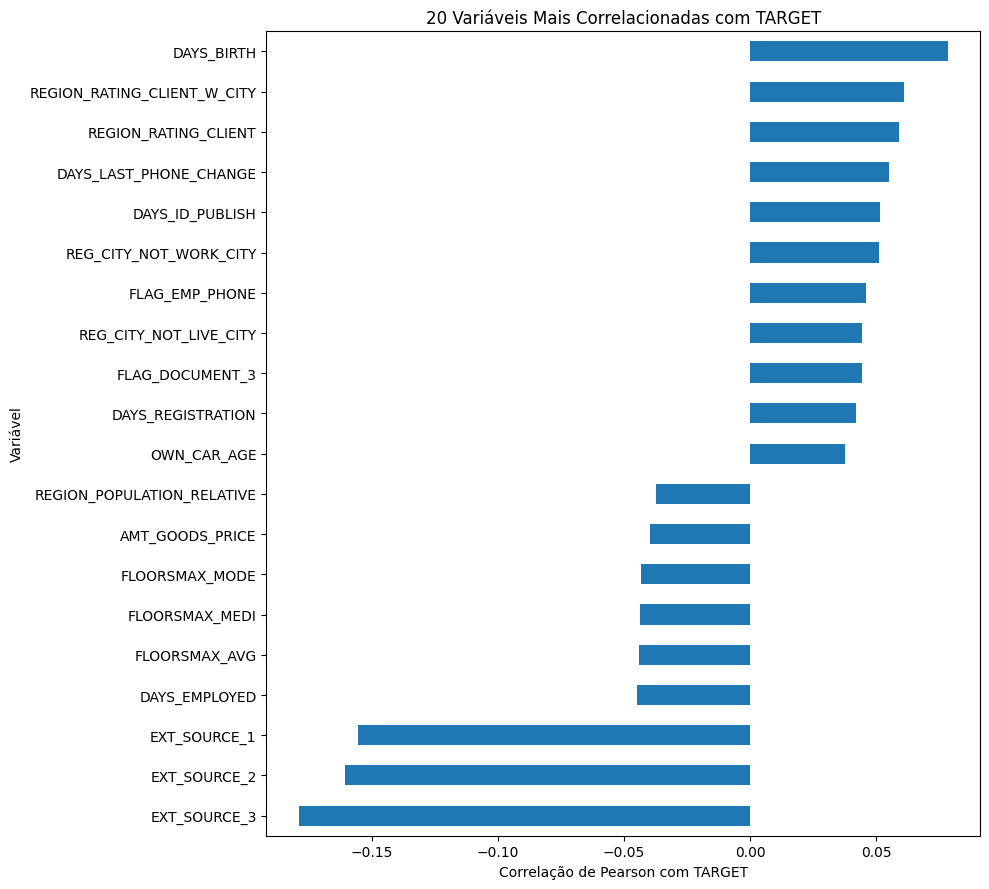

In [9]:
numeric_columns = application.select_dtypes(include=np.number).columns
numeric_columns = numeric_columns.drop(['TARGET', 'SK_ID_CURR'], errors='ignore')

corr_with_target = (
    application[numeric_columns]
    .corrwith(application['TARGET'])
    .rename('correlacao')
    .to_frame()
)
corr_with_target['correlacao_abs'] = corr_with_target['correlacao'].abs()
corr_with_target = corr_with_target.sort_values(
    'correlacao_abs',
    ascending=False,
)

top_corr_with_target = corr_with_target.head(20).copy()
display(top_corr_with_target.drop(columns='correlacao_abs'))

top_corr_with_target['correlacao'].sort_values().plot.barh(figsize=(10, 9))
plt.title('20 Variáveis Mais Correlacionadas com TARGET')
plt.xlabel('Correlação de Pearson com TARGET')
plt.ylabel('Variável')
plt.tight_layout()
corr_with_target_path = FIGURES_PATH / 'correlation_with_target.png'
plt.savefig(corr_with_target_path)
plt.show()
plt.close()

,variavel_a,variavel_b,correlacao
10,YEARS_BUILD_AVG,YEARS_BUILD_MEDI,0.998495
45,OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,0.998490
20,FLOORSMIN_AVG,FLOORSMIN_MEDI,0.997241
18,FLOORSMAX_AVG,FLOORSMAX_MEDI,0.997034
16,ENTRANCES_AVG,ENTRANCES_MEDI,0.996886
14,ELEVATORS_AVG,ELEVATORS_MEDI,0.996099
12,COMMONAREA_AVG,COMMONAREA_MEDI,0.995978
26,LIVINGAREA_AVG,LIVINGAREA_MEDI,0.995596
4,APARTMENTS_AVG,APARTMENTS_MEDI,0.995081
6,BASEMENTAREA_AVG,BASEMENTAREA_MEDI,0.994317


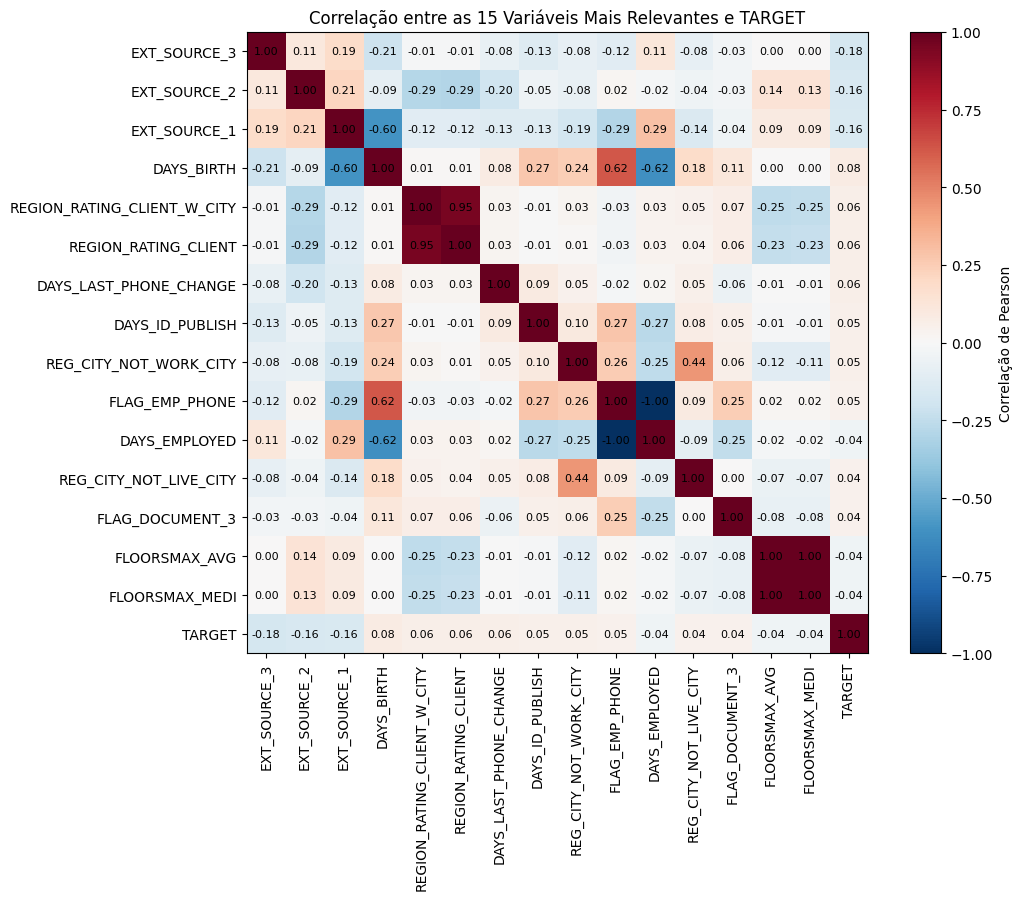

In [10]:
correlation_matrix = application[numeric_columns].corr()

upper_triangle = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape, dtype=bool),
            k=1,
        )
    )
)

stacked_pairs = upper_triangle.stack()
high_correlation_pairs = (
    stacked_pairs[stacked_pairs.abs() >= CORR_THRESHOLD]
    .rename('correlacao')
    .reset_index()
    .rename(
        columns={
            'level_0': 'variavel_a',
            'level_1': 'variavel_b',
        },
    )
    .sort_values('correlacao', ascending=False)
)

display(high_correlation_pairs)

top_features = corr_with_target.head(15).index.tolist()
subset_correlation = application[top_features + ['TARGET']].corr()

plt.figure(figsize=(11, 9))
plt.imshow(subset_correlation, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(label='Correlação de Pearson')
plt.xticks(
    ticks=range(len(subset_correlation)),
    labels=subset_correlation.columns,
    rotation=90,
)
plt.yticks(
    ticks=range(len(subset_correlation)),
    labels=subset_correlation.index,
)

for i in range(len(subset_correlation)):
    for j in range(len(subset_correlation)):
        value = subset_correlation.iloc[i, j]
        plt.text(
            j,
            i,
            f'{value:.2f}',
            ha='center',
            va='center',
            fontsize=8,
        )

plt.title('Correlação entre as 15 Variáveis Mais Relevantes e TARGET')
plt.tight_layout()
subset_corr_path = FIGURES_PATH / 'correlation_top_features.png'
plt.savefig(subset_corr_path)
plt.show()
plt.close()


As três variáveis mais correlacionadas com `TARGET` foram `EXT_SOURCE_3` (-0.1789), `EXT_SOURCE_2` (-0.1605) e `EXT_SOURCE_1` (-0.1553): pontuações externas de risco menores estão associadas a maior chance de dificuldade de pagamento. Em seguida aparecem `DAYS_BIRTH` (0.0782), `REGION_RATING_CLIENT_W_CITY` (0.0609) e `REGION_RATING_CLIENT` (0.0589).

Como `DAYS_BIRTH` é contado em dias e é negativo, a correlação positiva de 0.0782 indica que solicitantes mais jovens apresentam maior associação com a classe de dificuldade de pagamento. A correlação de `DAYS_EMPLOYED` (-0.0449) deve ser interpretada com cautela, pois a média dessa variável é distorcida pelo valor especial `365243` identificado na seção 6.4.

Na análise de redundância, foram identificados 46 pares com correlação igual ou superior a 0.95, formados principalmente pelos conjuntos `*_AVG`, `*_MODE` e `*_MEDI` das mesmas variáveis de moradia. Isso indica que apenas uma representação de cada conjunto deve ser mantida na seção 7. Destacam-se ainda `DAYS_EMPLOYED` com `FLAG_EMP_PHONE` (-0.9998) e `AMT_CREDIT` com `AMT_GOODS_PRICE` (0.9870), além de `REGION_RATING_CLIENT` com `REGION_RATING_CLIENT_W_CITY` (0.9508).

A correlação quase perfeita entre `DAYS_EMPLOYED` e `FLAG_EMP_PHONE` é um artefato do valor especial `365243`: todos os 55.374 registros com esse valor possuem `FLAG_EMP_PHONE = 0`. Sem esses registros, a correlação cai para aproximadamente 0.0023, ou seja, não há redundância real — o par será reconsiderado após o tratamento da seção 7.1.

Como os valores refletem os dados brutos, com eliminação por pares de valores ausentes, eles serão reconsiderados após o tratamento definido nas seções 7 a 10.


### 6.7 Comparação das Classes da Variável-Alvo

Esta subseção compara a distribuição das principais variáveis numéricas entre `TARGET = 0` e `TARGET = 1`, buscando evidências descritivas de diferenças entre os dois grupos.

In [11]:
comparison_columns = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3',
]
available_comparison = [
    column
    for column in comparison_columns
    if column in application.columns
]

comparison_rows = []
for column in available_comparison:
    grouped = application.groupby('TARGET')[column]
    for target_value in [0, 1]:
        series = grouped.get_group(target_value)
        comparison_rows.append({
            'variavel': column,
            'TARGET': target_value,
            'observacoes': int(series.notna().sum()),
            'media': series.mean(),
            'mediana': series.median(),
        })

comparison_summary = (
    pd.DataFrame(comparison_rows)
    .set_index(['variavel', 'TARGET'])
)

display(comparison_summary)

observacoes          media        mediana
variavel         TARGET                                           
AMT_INCOME_TOTAL 0            282686  169077.722266  148500.000000
                 1             24825  165611.760906  135000.000000
AMT_CREDIT       0            282686  602648.282002  517788.000000
                 1             24825  557778.527674  497520.000000
AMT_ANNUITY      0            282674   27163.623349   24876.000000
                 1             24825   26481.744290   25263.000000
AMT_GOODS_PRICE  0            282429  542736.795003  450000.000000
                 1             24804  488972.412554  450000.000000
DAYS_BIRTH       0            282686  -16138.176397  -15877.000000
                 1             24825  -14884.828077  -14282.000000
DAYS_EMPLOYED    0            282686   65696.146123   -1235.000000
                 1             24825   42394.675448   -1034.000000
EXT_SOURCE_1     0            124079       0.511461       0.517452
                 1             10054       0.386968       0.361675
EXT_SOURCE_2     0            282078       0.523479       0.573905
                 1             24773       0.410935       0.440381
EXT_SOURCE_3     0            227398       0.520969       0.546023
                 1             19148       0.390717       0.379100

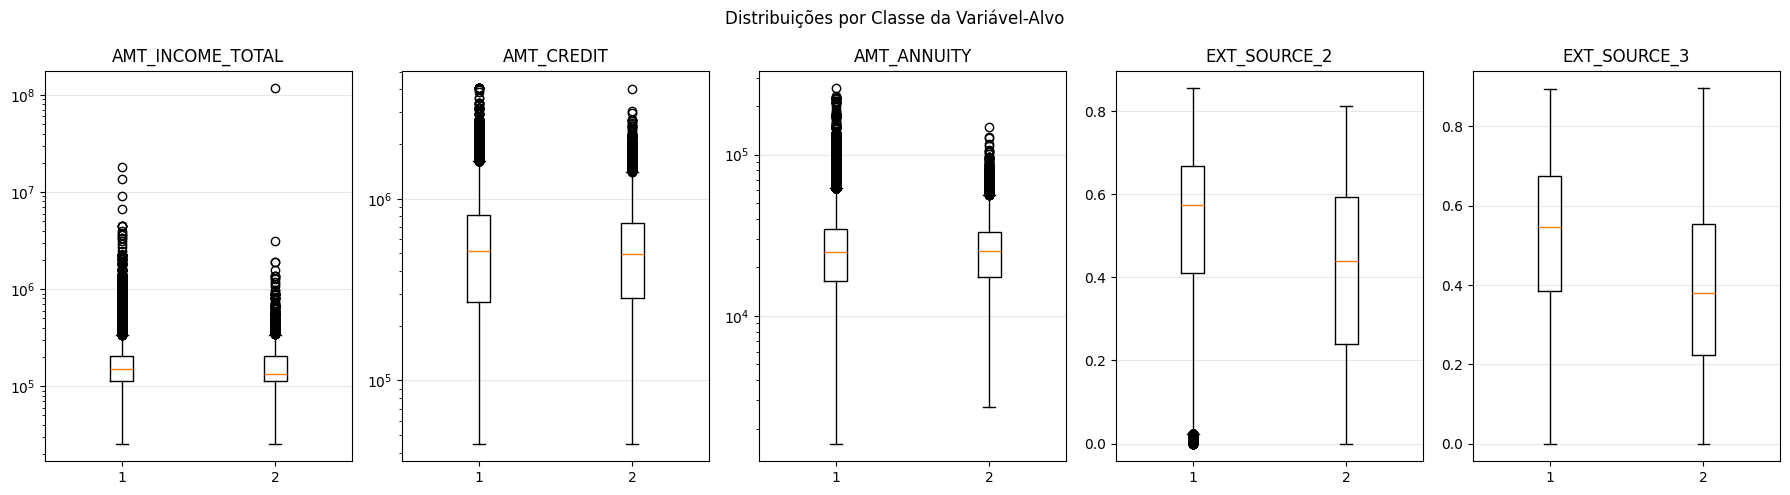

In [12]:
boxplot_columns = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3',
]
available_boxplot = [
    column
    for column in boxplot_columns
    if column in application.columns
]

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(available_boxplot),
    figsize=(18, 5),
    squeeze=False,
)

for ax, column in zip(axes.ravel(), available_boxplot):
    plot_data = application[['TARGET', column]].dropna()
    groups = [
        plot_data.loc[plot_data['TARGET'] == 0, column],
        plot_data.loc[plot_data['TARGET'] == 1, column],
    ]
    ax.boxplot(groups, label=['TARGET = 0', 'TARGET = 1'])
    if column.startswith('AMT_'):
        ax.set_yscale('log')
    ax.set_title(column)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribuições por Classe da Variável-Alvo')
plt.tight_layout()
boxplot_path = FIGURES_PATH / 'target_comparison_boxplots.png'
plt.savefig(boxplot_path)
plt.show()
plt.close()

Os solicitantes da classe `TARGET = 1` apresentam, em mediana, renda menor (R$ 135.000 contra R$ 148.500) e idade menor (aproximadamente 39,1 anos contra 43,5 anos). As três pontuações externas apresentam diferenças marcantes: a mediana de `EXT_SOURCE_3` é 0,379 para `TARGET = 1` e 0,546 para `TARGET = 0`, padrão que se repete em `EXT_SOURCE_1` e `EXT_SOURCE_2`. Valores de pontuação externa mais baixos indicam maior risco.

O tempo mediano de emprego (`DAYS_EMPLOYED`) é ligeiramente menor na classe positiva (-1.034 dias contra -1.235 dias), embora a média da variável seja distorcida pelo valor especial `365243` e não deva ser comparada diretamente. A mediana do valor solicitado é levemente menor para `TARGET = 1` (R$ 497.520 contra R$ 517.788), e a parcela mediana é semelhante entre as classes.


### 6.8 Ausência de Informação e Taxa de Dificuldade por Categoria

Esta subseção investiga se a ausência de informações se associa a `TARGET` e como a taxa da classe positiva varia entre as categorias das principais variáveis categóricas.

In [13]:
columns_with_missing = numeric_columns[
    application[numeric_columns].isna().sum() > 0
]

with np.errstate(invalid='ignore', divide='ignore'):
    missing_signal = (
        application[columns_with_missing]
        .isna()
        .corrwith(application['TARGET'])
        .rename('correlacao')
        .to_frame()
        .sort_values('correlacao', ascending=False)
    )

display(missing_signal.head(15))


,correlacao
TOTALAREA_MODE,0.041168
ENTRANCES_MODE,0.040872
ENTRANCES_AVG,0.040872
ENTRANCES_MEDI,0.040872
FLOORSMAX_MODE,0.040847
FLOORSMAX_AVG,0.040847
FLOORSMAX_MEDI,0.040847
YEARS_BEGINEXPLUATATION_MODE,0.040554
YEARS_BEGINEXPLUATATION_AVG,0.040554
YEARS_BEGINEXPLUATATION_MEDI,0.040554


In [14]:
target_rate_columns = [
    'NAME_CONTRACT_TYPE',
    'CODE_GENDER',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_INCOME_TYPE',
]
available_rate_columns = [
    column
    for column in target_rate_columns
    if column in application.columns
]

for column in available_rate_columns:
    default_rate = (
        application[[column, 'TARGET']]
        .groupby(column)['TARGET']
        .agg(['count', 'mean'])
        .rename(columns={'count': 'quantidade', 'mean': 'taxa_target_1'})
        .query('quantidade >= 1000')
        .sort_values('taxa_target_1', ascending=False)
    )
    print(f'--- {column} ---')
    display(default_rate)

--- NAME_CONTRACT_TYPE ---


,quantidade,taxa_target_1
NAME_CONTRACT_TYPE,,
Cash loans,278232,0.083459
Revolving loans,29279,0.054783


--- CODE_GENDER ---


,quantidade,taxa_target_1
CODE_GENDER,,
M,105059,0.101419
F,202448,0.069993


--- NAME_EDUCATION_TYPE ---


,quantidade,taxa_target_1
NAME_EDUCATION_TYPE,,
Lower secondary,3816,0.109277
Secondary / secondary special,218391,0.089399
Incomplete higher,10277,0.084850
Higher education,74863,0.053551


--- NAME_FAMILY_STATUS ---


,quantidade,taxa_target_1
NAME_FAMILY_STATUS,,
Civil marriage,29775,0.099446
Single / not married,45444,0.098077
Separated,19770,0.081942
Married,196432,0.075599
Widow,16088,0.058242


--- NAME_INCOME_TYPE ---


,quantidade,taxa_target_1
NAME_INCOME_TYPE,,
Working,158774,0.095885
Commercial associate,71617,0.074843
State servant,21703,0.057550
Pensioner,55362,0.053864


Para variáveis como `TOTALAREA_MODE`, `ENTRANCES_*` e `FLOORSMAX_*`, a própria ausência de informação apresenta correlação pequena, mas positiva, com `TARGET` (cerca de 0.040). Isso indica que o fato de determinadas informações de moradia não terem sido preenchidas tem associação leve com a classe de dificuldade de pagamento, o que justifica avaliar indicadores de ausência na seção 7.

Entre as variáveis categóricas, as maiores taxas de `TARGET = 1` foram observadas em contratos do tipo Cash loans (8,35%, contra 5,48% em Revolving loans), em solicitantes do sexo masculino (10,14%, contra 7,00% no feminino) e entre quem possui menor escolaridade (10,93% em Lower secondary, contra 5,36% em Higher education): quanto menor a escolaridade, maior a taxa de dificuldade. Por tipo de renda, trabalhadores assalariados do setor privado (Working) apresentam a maior taxa (9,59%), enquanto pensionistas (5,39%) apresentam a menor.

Esses resultados são descritivos e serão consolidados nas decisões das seções 7 a 10.

## 7. Limpeza dos Dados e Engenharia de Atributos

Esta seção prepara a base para a modelagem aplicando as evidências da análise exploratória:

1. tratamento do valor especial `365243` em `DAYS_EMPLOYED`;
2. remoção de variáveis redundantes (variantes `*_AVG`, `*_MODE` e `*_MEDI`);
3. tratamento da categoria especial `XNA` em `CODE_GENDER`;
4. criação de atributos com interpretação financeira.

Nesta seção são aplicadas apenas correções determinísticas e decisões estruturais (baseadas no padrão dos nomes de colunas), definidas a priori e motivadas pela EDA. O limiar de ausência, a imputação, a codificação e a padronização — toda estatística aprendida dos dados — são definidos e calculados somente sobre o treinamento (seções 9 e 10). O arquivo externo `application_test.csv` (sem rótulos) não participa de nenhuma decisão.


### 7.1 Tratamento do Valor Especial em DAYS_EMPLOYED

O valor `365243` em `DAYS_EMPLOYED` representa uma situação especial de informação de emprego. Nesta etapa ele é sinalizado por uma variável binária e convertido para ausente.

In [15]:
application_model = application.copy()

days_employed_anomaly = (
    application_model['DAYS_EMPLOYED'] == DAYS_EMPLOYED_SPECIAL
)
application_model['DAYS_EMPLOYED_ANOMALY'] = days_employed_anomaly.astype('int8')

application_model['DAYS_EMPLOYED'] = application_model['DAYS_EMPLOYED'].replace(
    DAYS_EMPLOYED_SPECIAL,
    np.nan,
)

anomaly_count = int(days_employed_anomaly.sum())
anomaly_rate = days_employed_anomaly.mean()

days_employed_check = application_model['DAYS_EMPLOYED'] == DAYS_EMPLOYED_SPECIAL
anomaly_check = int(days_employed_check.sum())

assert anomaly_check == 0, (
    f'Valores especiais remanescentes em DAYS_EMPLOYED: {anomaly_check}'
)

print(
    f'Registros com o valor especial {DAYS_EMPLOYED_SPECIAL} '
    f'antes da remoção: {anomaly_count:,}'
)
print(f'Proporção em relação à base: {anomaly_rate:.2%}')
print(
    f'Registros com o valor especial {DAYS_EMPLOYED_SPECIAL} '
    f'depois da remoção: {anomaly_check:,}'
)


Registros com o valor especial 365243 antes da remoção: 55,374
Proporção em relação à base: 18.01%
Registros com o valor especial 365243 depois da remoção: 0


### 7.2 Remoção de Variáveis Redundantes

Conforme identificado na seção 6.6, as variantes `_AVG`, `_MODE` e `_MEDI` das mesmas variáveis são quase perfeitamente correlacionadas. Será mantida apenas a variante `_MEDI` de cada grupo, pois a mediana é  mais robusta contra valores extremos.

In [16]:
variant_groups = {}
for column in application_model.columns:
    match = re.fullmatch(r'(.+)_(AVG|MODE|MEDI)', column)
    if match is not None:
        variant_groups.setdefault(match.group(1), []).append(column)

redundant_columns = []
kept_variants = []

for base, variants in variant_groups.items():
    if len(variants) < 2:
        continue
    for preferred_suffix in ('_MEDI', '_AVG', '_MODE'):
        candidate = f'{base}{preferred_suffix}'
        if candidate in variants:
            kept = candidate
            break
    kept_variants.append(kept)
    redundant_columns.extend(
        column for column in variants if column != kept
    )

print(f'Grupos com variantes redundantes: {len(kept_variants)}')
print(f'Variáveis removidas por redundância: {len(redundant_columns)}')
print('Variantes mantidas:')
print(sorted(kept_variants))

application_model = application_model.drop(columns=redundant_columns)


Grupos com variantes redundantes: 14
Variáveis removidas por redundância: 28
Variantes mantidas:
['APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI']


### 7.3 Tratamento da Categoria Especial XNA em CODE_GENDER

A categoria `XNA` em `CODE_GENDER` representa gênero desconhecido (4 registros na base) e será convertida em valor ausente, para que a imputação da seção 10 a trate como qualquer outra ausência. A alternativa de manter a categoria foi descartada por representar não-informação em quantidade insignificante de registros.


In [17]:
code_gender_xna_mask = application_model['CODE_GENDER'].eq('XNA')
code_gender_xna_count = int(code_gender_xna_mask.sum())

application_model.loc[code_gender_xna_mask, 'CODE_GENDER'] = np.nan

assert code_gender_xna_count == 4, (
    f'Esperado 4 registros XNA em CODE_GENDER; encontrado: {code_gender_xna_count}'
)

print(
    f'Categorias XNA convertidas em ausentes em CODE_GENDER: '
    f'{code_gender_xna_count}'
)


Categorias XNA convertidas em ausentes em CODE_GENDER: 4


### 7.4 Engenharia de Atributos

Serão criados atributos com interpretação financeira e demográfica. As divisões utilizam `safe_ratio`, que converte denominadores nulos em ausentes — evita divisão por zero e protege a aplicação do mesmo procedimento em `application_test.csv` na submissão.

Além das razões já planejadas, são incluídas razões e agregações consagradas pela solução vencedora da competição Home Credit: `LTV` (crédito sobre o valor do bem), `DOWN_PAYMENT` (entrada implícita) e `EXT_SOURCE_MEAN` (agregação das pontuações externas).


In [18]:
def safe_ratio(numerator, denominator):
    denominator_without_zero = denominator.mask(denominator.eq(0))
    return numerator.div(denominator_without_zero)


application_model['AGE_YEARS'] = (
    -application_model['DAYS_BIRTH'] / DAYS_PER_YEAR
)
application_model['EMPLOYMENT_YEARS'] = (
    -application_model['DAYS_EMPLOYED'] / DAYS_PER_YEAR
)
application_model['CREDIT_INCOME_RATIO'] = safe_ratio(
    application_model['AMT_CREDIT'],
    application_model['AMT_INCOME_TOTAL'],
)
application_model['ANNUITY_INCOME_RATIO'] = safe_ratio(
    application_model['AMT_ANNUITY'],
    application_model['AMT_INCOME_TOTAL'],
)
application_model['CREDIT_ANNUITY_RATIO'] = safe_ratio(
    application_model['AMT_CREDIT'],
    application_model['AMT_ANNUITY'],
)
application_model['CREDIT_PER_FAMILY_MEMBER'] = safe_ratio(
    application_model['AMT_CREDIT'],
    application_model['CNT_FAM_MEMBERS'],
)
application_model['CHILDREN_PER_FAMILY_MEMBER'] = safe_ratio(
    application_model['CNT_CHILDREN'],
    application_model['CNT_FAM_MEMBERS'],
)
application_model['EXT_SOURCE_1_MISSING'] = (
    application_model['EXT_SOURCE_1'].isna().astype('int8')
)
application_model['LTV'] = safe_ratio(
    application_model['AMT_CREDIT'],
    application_model['AMT_GOODS_PRICE'],
)
application_model['DOWN_PAYMENT'] = (
    application_model['AMT_GOODS_PRICE'] - application_model['AMT_CREDIT']
)
application_model['EXT_SOURCE_MEAN'] = (
    application_model[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']]
    .mean(axis=1, skipna=True)
)

assert application_model.shape == (307511, 106), (
    f'Shape inesperado após a engenharia: {application_model.shape}'
)
numeric_model = application_model.select_dtypes(include=np.number)
assert not np.isinf(numeric_model.to_numpy()).any(), (
    'Valores infinitos na base modelada.'
)


### 7.5 Verificação das Transformações

As estatísticas descritivas dos atributos criados são verificadas para confirmar a ausência de valores infinitos e dimensionar a imputação necessária na seção 10.


In [19]:
new_feature_names = [
    'AGE_YEARS',
    'EMPLOYMENT_YEARS',
    'CREDIT_INCOME_RATIO',
    'ANNUITY_INCOME_RATIO',
    'CREDIT_ANNUITY_RATIO',
    'CREDIT_PER_FAMILY_MEMBER',
    'CHILDREN_PER_FAMILY_MEMBER',
    'EXT_SOURCE_1_MISSING',
    'LTV',
    'DOWN_PAYMENT',
    'EXT_SOURCE_MEAN',
]

engineered_feature_quality = pd.DataFrame({
    'valores_ausentes': application_model[new_feature_names].isna().sum(),
    'valores_infinitos': np.isinf(
        application_model[new_feature_names]
    ).sum(),
})

display(engineered_feature_quality)


,valores_ausentes,valores_infinitos
AGE_YEARS,0,0
EMPLOYMENT_YEARS,55374,0
CREDIT_INCOME_RATIO,0,0
ANNUITY_INCOME_RATIO,12,0
CREDIT_ANNUITY_RATIO,12,0
CREDIT_PER_FAMILY_MEMBER,2,0
CHILDREN_PER_FAMILY_MEMBER,2,0
EXT_SOURCE_1_MISSING,0,0
LTV,278,0
DOWN_PAYMENT,278,0


### Documentação das Decisões de Limpeza

As decisões desta seção foram baseadas nas evidências da análise exploratória (seções 6.4 a 6.8).

- `DAYS_EMPLOYED`: o valor especial `365243` ocorreu em 55.374 registros (18,01% da base) e representa a ausência de informação de emprego. Foi criado o indicador binário `DAYS_EMPLOYED_ANOMALY` e o valor original foi convertido para ausente, a ser imputado na seção 10.
- Variáveis redundantes: os 14 grupos de variantes `*_AVG`, `*_MODE` e `*_MEDI` apresentaram correlações de pelo menos 0.95 entre si (seção 6.6). Foi mantida apenas a variante `_MEDI` de cada grupo (28 variáveis removidas). A seleção é determinística — baseada no padrão do nome e em prioridade fixa (`_MEDI` > `_AVG` > `_MODE`) — e não utiliza estatísticas dos dados.
- `CODE_GENDER`: a categoria `XNA` (4 registros) foi convertida em ausente, pois representa não-informação.
- `SK_ID_CURR` e `TARGET` serão preservadas fora de `X` (seção 8); `SK_ID_CURR` não será utilizada como característica preditiva.
- `DAYS_BIRTH` e `DAYS_EMPLOYED` serão retirados de `X` na seção 8, pois `AGE_YEARS` e `EMPLOYMENT_YEARS` são transformações lineares dessas variáveis.
- Os filtros estatísticos (colunas com 60% ou mais de ausência e colunas constantes) serão aplicados na seção 10, com as estatísticas calculadas somente sobre o treinamento — o teste interno não participa dessas decisões.

Atributos criados:

| Atributo | Definição | Interpretação |
|---|---|---|
| `AGE_YEARS` | `-DAYS_BIRTH / 365.25` | Idade do solicitante em anos |
| `EMPLOYMENT_YEARS` | `-DAYS_EMPLOYED / 365.25` | Tempo de emprego em anos (ausente para a anomalia) |
| `CREDIT_INCOME_RATIO` | `AMT_CREDIT / AMT_INCOME_TOTAL` | Endividamento: crédito em relação à renda |
| `ANNUITY_INCOME_RATIO` | `AMT_ANNUITY / AMT_INCOME_TOTAL` | Comprometimento da renda com a parcela |
| `CREDIT_ANNUITY_RATIO` | `AMT_CREDIT / AMT_ANNUITY` | Relação entre crédito e parcela (prazo implícito) |
| `CREDIT_PER_FAMILY_MEMBER` | `AMT_CREDIT / CNT_FAM_MEMBERS` | Crédito por integrante da família |
| `CHILDREN_PER_FAMILY_MEMBER` | `CNT_CHILDREN / CNT_FAM_MEMBERS` | Filhos por integrante da família |
| `LTV` | `AMT_CREDIT / AMT_GOODS_PRICE` | Loan-to-value: crédito sobre o valor do bem |
| `DOWN_PAYMENT` | `AMT_GOODS_PRICE - AMT_CREDIT` | Entrada implícita (negativa quando o crédito supera o bem) |
| `EXT_SOURCE_MEAN` | média de `EXT_SOURCE_1/2/3` | Pontuação externa agregada (ausente apenas quando as três faltam) |
| `EXT_SOURCE_1_MISSING` | `EXT_SOURCE_1.isna()` | Indicador de ausência da pontuação externa 1 |
| `DAYS_EMPLOYED_ANOMALY` | `DAYS_EMPLOYED == 365243` | Indicador da situação especial de emprego |

`LTV`, `DOWN_PAYMENT` e `EXT_SOURCE_MEAN` seguem razões e agregações da solução vencedora da competição Home Credit. A base resultante possui 307.511 linhas e 106 colunas. As razões usam `safe_ratio` (denominador nulo → ausente).


### 7.6 Liberação de Memória

A partir deste ponto, a base bruta `application` não é mais necessária. Sua remoção libera aproximadamente 325 MB de memória, que podem ser úteis ao treinar a Rede Neural na seção 11. As células da seção 6 que dependem de `application` devem ser executadas antes desta célula; as seções seguintes utilizam somente `application_model`.


In [20]:
del application
gc.collect()

print('Base bruta `application` removida da memória.')


Base bruta `application` removida da memória.


## 8. Construção de X e y

A base limpa `application_model` (307.511 × 106) é separada em matriz de características, vetor-alvo e identificador:

- `X`: todas as colunas exceto `SK_ID_CURR` e `TARGET` e exceto `DAYS_BIRTH` e `DAYS_EMPLOYED` (convertidos em `AGE_YEARS` e `EMPLOYMENT_YEARS` na seção 7.4 — transformações lineares que duplicariam a informação). Resultado esperado: **307.511 × 102**.
- `y`: a coluna `TARGET` (sem valores ausentes; valores em {0, 1}).
- `ids`: a coluna `SK_ID_CURR`, preservada fora de `X` para rastreabilidade — não é característica preditiva.

A imputação, a codificação e a padronização **não** são aplicadas aqui: pertencem à seção 10, com parâmetros ajustados somente no treinamento.


In [21]:
y = application_model.pop('TARGET')
ids = application_model.pop('SK_ID_CURR')

X = application_model.drop(columns=['DAYS_BIRTH', 'DAYS_EMPLOYED'])

del application_model

assert X.shape == (307511, 102), f'Shape inesperado para X: {X.shape}'
assert y.shape == (307511,), f'Shape inesperado para y: {y.shape}'
assert y.isna().sum() == 0, 'y possui valores ausentes.'
assert set(y.unique()) == {0, 1}, 'y possui valores fora de {0, 1}.'
assert ids.is_unique, 'SK_ID_CURR possui duplicatas.'
assert X.columns.is_unique, 'X possui colunas duplicadas.'

numeric_X = X.select_dtypes(include=np.number)
assert not np.isinf(numeric_X.to_numpy()).any(), 'X possui valores infinitos.'

missing_columns_X = X.columns[X.isna().any()].tolist()
total_missing_X = int(X.isna().sum().sum())

categorical_columns = X.select_dtypes(
    include=['object', 'category', 'string']
).columns.tolist()

print(f'Dimensão de X: {X.shape}')
print(f'Dimensão de y: {y.shape}')
print(f'Variáveis categóricas em X: {len(categorical_columns)}')
print(f'Colunas com valores ausentes em X: {len(missing_columns_X)}')
print(f'Total de valores ausentes em X: {total_missing_X:,}')
display(X.dtypes.astype(str).value_counts().rename('quantidade'))
print('Variáveis categóricas:')
print(categorical_columns)
print(f'Valores ausentes em y: {int(y.isna().sum())}')
print(f'Identificador preservado: {ids.name} ({ids.shape[0]} valores únicos)')


Dimensão de X: (307511, 102)
Dimensão de y: (307511,)
Variáveis categóricas em X: 16
Colunas com valores ausentes em X: 48
Total de valores ausentes em X: 4,176,439


float64    47
int64      37
object     16
int8        2
Name: quantidade, dtype: int64

Variáveis categóricas:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']
Valores ausentes em y: 0
Identificador preservado: SK_ID_CURR (307511 valores únicos)


## 9. Divisão em Treinamento, Validação e Teste

A base rotulada é dividida em **70% treinamento, 15% validação e 15% teste**, estratificados por `TARGET`, com `RANDOM_STATE = 42`.

- O **treinamento** ajusta modelos e transformadores.
- A **validação** apoia decisões de desenvolvimento e hiperparâmetros.
- O **teste** permanece isolado até a avaliação final (seção 13) e não participa de nenhuma decisão de modelagem ou pré-processamento.

O arquivo `application_test.csv` (sem `TARGET`) não é utilizado como teste acadêmico porque não permite calcular métricas de classificação; ao final, será usado somente para predições de submissão.


In [22]:
original_row_count = len(y)
indices = np.arange(original_row_count)

idx_train_val, idx_test = train_test_split(
    indices,
    test_size=0.15,
    stratify=y,
    random_state=RANDOM_STATE,
)

idx_train, idx_val = train_test_split(
    idx_train_val,
    test_size=0.15 / 0.85,
    stratify=y.iloc[idx_train_val],
    random_state=RANDOM_STATE,
)

# Materializa cada subconjunto apenas uma vez e preserva os índices originais
X_train = X.iloc[idx_train]
X_val = X.iloc[idx_val]
X_test = X.iloc[idx_test]

y_train = y.iloc[idx_train]
y_val = y.iloc[idx_val]
y_test = y.iloc[idx_test]

ids_train = ids.iloc[idx_train]
ids_val = ids.iloc[idx_val]
ids_test = ids.iloc[idx_test]

# Verificações de cobertura, exclusividade e alinhamento
split_row_count = len(X_train) + len(X_val) + len(X_test)

if split_row_count != original_row_count:
    raise ValueError(
        'A soma das linhas dos subconjuntos difere do total original.'
    )

index_groups = {
    'Treino': idx_train,
    'Validação': idx_val,
    'Teste': idx_test,
}

for split_name, split_indices in index_groups.items():
    if np.unique(split_indices).size != len(split_indices):
        raise ValueError(
            f'Foram encontrados índices duplicados em {split_name}.'
        )

overlap_sizes = {
    'treino e validação': np.intersect1d(
        idx_train,
        idx_val,
        assume_unique=True,
    ).size,
    'treino e teste': np.intersect1d(
        idx_train,
        idx_test,
        assume_unique=True,
    ).size,
    'validação e teste': np.intersect1d(
        idx_val,
        idx_test,
        assume_unique=True,
    ).size,
}

if any(overlap_sizes.values()):
    raise ValueError(
        f'Foi detectada sobreposição entre subconjuntos: {overlap_sizes}'
    )

combined_indices = np.concatenate([
    idx_train,
    idx_val,
    idx_test,
])
assignment_counts = np.bincount(
    combined_indices,
    minlength=original_row_count,
)

if not np.all(assignment_counts == 1):
    raise ValueError(
        'Cada registro deve aparecer exatamente uma vez nos subconjuntos.'
    )

split_objects = {
    'Treino': (X_train, y_train, ids_train),
    'Validação': (X_val, y_val, ids_val),
    'Teste': (X_test, y_test, ids_test),
}

for split_name, (X_split, y_split, ids_split) in split_objects.items():
    if not (len(X_split) == len(y_split) == len(ids_split)):
        raise ValueError(
            f'X, y e ids possuem tamanhos diferentes em {split_name}.'
        )

    if not (
        X_split.index.equals(y_split.index)
        and X_split.index.equals(ids_split.index)
    ):
        raise ValueError(
            f'X, y e ids não estão alinhados em {split_name}.'
        )

original_target_1_rate = float(y.mean())
target_1_rates = {
    split_name: float(y_split.mean())
    for split_name, (_, y_split, _) in split_objects.items()
}
stratification_tolerance = 0.001

if any(
    abs(rate - original_target_1_rate) > stratification_tolerance
    for rate in target_1_rates.values()
):
    raise ValueError(
        'A proporção de TARGET = 1 não foi preservada pela estratificação.'
    )

# Confirma, coluna a coluna, que o teste é uma seleção inalterada de X
test_untouched = (
    X_test.index.equals(X.index[idx_test])
    and X_test.columns.equals(X.columns)
    and X_test.dtypes.equals(X.dtypes)
    and all(
        X_test[column].equals(X[column].iloc[idx_test])
        for column in X.columns
    )
)

if not test_untouched:
    raise ValueError(
        'O conjunto de teste difere da seleção original antes do pré-processamento.'
    )


def build_split_summary(split_name, y_split):
    target_counts = y_split.value_counts()
    return {
        'conjunto': split_name,
        'registros': len(y_split),
        'percentual': len(y_split) / original_row_count * 100,
        'TARGET 0': int(target_counts.get(0, 0)),
        'TARGET 1': int(target_counts.get(1, 0)),
        'percentual TARGET 1': float(y_split.mean() * 100),
    }


split_summary = pd.DataFrame([
    build_split_summary('Treino', y_train),
    build_split_summary('Validação', y_val),
    build_split_summary('Teste', y_test),
]).set_index('conjunto')

split_summary_display = split_summary.copy()
split_summary_display['percentual'] = (
    split_summary_display['percentual'].map(lambda value: f'{value:.2f}%')
)
split_summary_display['percentual TARGET 1'] = (
    split_summary_display['percentual TARGET 1']
    .map(lambda value: f'{value:.4f}%')
)

# As próximas seções utilizam apenas os subconjuntos separados
del X, y, ids, indices, idx_train_val
del combined_indices, assignment_counts, split_objects

print(f'Total de registros preservado: {split_row_count:,}')
print(
    'Sobreposição entre treino, validação e teste: '
    f'{sum(overlap_sizes.values())}'
)
print('Cada registro foi atribuído exatamente uma vez: confirmado')
print('Alinhamento entre X, y e ids em cada conjunto: confirmado')
print('Estratificação de TARGET preservada: confirmada')
print('Conjunto de teste sem transformações aprendidas: confirmado')
display(split_summary_display)


Total de registros preservado: 307,511
Sobreposição entre treino, validação e teste: 0
Cada registro foi atribuído exatamente uma vez: confirmado
Alinhamento entre X, y e ids em cada conjunto: confirmado
Estratificação de TARGET preservada: confirmada
Conjunto de teste sem transformações aprendidas: confirmado


,registros,percentual,TARGET 0,TARGET 1,percentual TARGET 1
conjunto,,,,,
Treino,215257,70.00%,197880,17377,8.0727%
Validação,46127,15.00%,42403,3724,8.0734%
Teste,46127,15.00%,42403,3724,8.0734%


### 10.1 Seleção de Variáveis a partir do Treinamento

As colunas com 60% ou mais de valores ausentes e as colunas constantes (ou sem informação) são identificadas **somente no treinamento** e removidas dos três conjuntos. O teste não participa dessas estatísticas — garantia verificável de que nenhuma decisão de pré-processamento usa informação do teste.


In [23]:
original_feature_count = X_train.shape[1]
missing_rates_train = X_train.isna().mean()
columns_removed_missing = sorted(
    missing_rates_train[
        missing_rates_train >= MISSING_THRESHOLD
    ].index.tolist()
)

columns_after_missing = [
    column
    for column in X_train.columns
    if column not in columns_removed_missing
]
columns_removed_constant = sorted([
    column
    for column in columns_after_missing
    if X_train[column].nunique(dropna=True) <= 1
])

columns_removed_preprocessing = (
    columns_removed_missing + columns_removed_constant
)

# Aplica aos três conjuntos apenas as decisões aprendidas no treino
X_train = X_train.drop(columns=columns_removed_preprocessing)
X_val = X_val.drop(columns=columns_removed_preprocessing)
X_test = X_test.drop(columns=columns_removed_preprocessing)

remaining_feature_count = X_train.shape[1]
numerical_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()
categorical_features = X_train.select_dtypes(
    include=['object', 'category', 'string']
).columns.tolist()

if not (
    X_train.columns.equals(X_val.columns)
    and X_train.columns.equals(X_test.columns)
):
    raise ValueError(
        'Treino, validação e teste possuem colunas diferentes.'
    )

if len(numerical_features) + len(categorical_features) != remaining_feature_count:
    raise ValueError(
        'Uma ou mais colunas não foram classificadas como numéricas ou categóricas.'
    )

forbidden_features = {
    'TARGET',
    'SK_ID_CURR',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
}

if forbidden_features.intersection(X_train.columns):
    raise ValueError(
        'Uma ou mais colunas proibidas permaneceram nas características.'
    )

print(f'Variáveis antes dos filtros: {original_feature_count:,}')
print(
    'Colunas removidas por ausência >= 60%: '
    f'{len(columns_removed_missing):,}'
)
print(f'Nomes: {columns_removed_missing}')
print(
    'Colunas constantes ou sem informação removidas: '
    f'{len(columns_removed_constant):,}'
)
print(f'Nomes: {columns_removed_constant}')
print(f'Variáveis restantes: {remaining_feature_count:,}')
print(f'Variáveis numéricas: {len(numerical_features):,}')
print(f'Variáveis categóricas: {len(categorical_features):,}')


Variáveis antes dos filtros: 102
Colunas removidas por ausência >= 60%: 7
Nomes: ['COMMONAREA_MEDI', 'FLOORSMIN_MEDI', 'FONDKAPREMONT_MODE', 'LIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'OWN_CAR_AGE', 'YEARS_BUILD_MEDI']
Colunas constantes ou sem informação removidas: 1
Nomes: ['FLAG_DOCUMENT_12']
Variáveis restantes: 94
Variáveis numéricas: 79
Variáveis categóricas: 15


### 10.2 Definição dos Transformadores

Dois pipelines distintos são definidos: um para a **Rede Neural** (imputação + One-Hot + padronização) e outro para a **Árvore de Decisão** (imputação + One-Hot, sem padronização — a árvore não exige escala). Valores numéricos ausentes são imputados pela mediana; categóricos, pelo valor mais frequente. Categorias desconhecidas são preservadas com `handle_unknown='ignore'`. As matrizes resultantes usam `float32` em formato CSR para economia de memória.


In [24]:
def to_float32(values):
    return values.astype(np.float32, copy=False)


nn_numerical_pipeline = Pipeline(steps=[
    (
        'imputer',
        SimpleImputer(
            strategy='median',
            copy=False,
            keep_empty_features=True,
        ),
    ),
    ('scaler', StandardScaler(copy=False)),
    (
        'float32',
        FunctionTransformer(
            to_float32,
            feature_names_out='one-to-one',
        ),
    ),
])

nn_categorical_pipeline = Pipeline(steps=[
    (
        'imputer',
        SimpleImputer(
            strategy='most_frequent',
            copy=False,
            keep_empty_features=True,
        ),
    ),
    (
        'onehot',
        OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=True,
            dtype=np.float32,
        ),
    ),
])

tree_numerical_pipeline = Pipeline(steps=[
    (
        'imputer',
        SimpleImputer(
            strategy='median',
            copy=False,
            keep_empty_features=True,
        ),
    ),
    (
        'float32',
        FunctionTransformer(
            to_float32,
            feature_names_out='one-to-one',
        ),
    ),
])

tree_categorical_pipeline = Pipeline(steps=[
    (
        'imputer',
        SimpleImputer(
            strategy='most_frequent',
            copy=False,
            keep_empty_features=True,
        ),
    ),
    (
        'onehot',
        OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=True,
            dtype=np.float32,
        ),
    ),
])

nn_preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', nn_numerical_pipeline, numerical_features),
        ('categorical', nn_categorical_pipeline, categorical_features),
    ],
    remainder='drop',
    sparse_threshold=1.0,
    n_jobs=1,
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', tree_numerical_pipeline, numerical_features),
        ('categorical', tree_categorical_pipeline, categorical_features),
    ],
    remainder='drop',
    sparse_threshold=1.0,
    n_jobs=1,
)


### 10.3 Pré-processamento para a Rede Neural e a Árvore de Decisão

Cada pré-processador é ajustado exclusivamente com `X_train` (`fit_transform`) e aplicado a validação e teste apenas com `transform`. Um registro de auditoria documenta cada operação para a verificação da subseção seguinte.


In [25]:
preprocessing_audit = []


def fit_transform_training(preprocessor, features, preprocessor_name):
    preprocessing_audit.append({
        'preprocessador': preprocessor_name,
        'operação': 'fit_transform',
        'conjunto': 'X_train',
    })
    return preprocessor.fit_transform(features)


def transform_without_fit(
    preprocessor,
    features,
    preprocessor_name,
    split_name,
):
    preprocessing_audit.append({
        'preprocessador': preprocessor_name,
        'operação': 'transform',
        'conjunto': split_name,
    })
    return preprocessor.transform(features)


def ensure_csr_float32(matrix):
    if sparse.issparse(matrix):
        matrix = matrix.tocsr()
    else:
        matrix = sparse.csr_matrix(matrix)

    return matrix.astype(np.float32, copy=False)


X_train_nn = ensure_csr_float32(
    fit_transform_training(
        nn_preprocessor,
        X_train,
        'nn_preprocessor',
    )
)
X_val_nn = ensure_csr_float32(
    transform_without_fit(
        nn_preprocessor,
        X_val,
        'nn_preprocessor',
        'X_val',
    )
)
X_test_nn = ensure_csr_float32(
    transform_without_fit(
        nn_preprocessor,
        X_test,
        'nn_preprocessor',
        'X_test',
    )
)
gc.collect()

print('Caminho da Rede Neural transformado com sucesso.')

X_train_tree = ensure_csr_float32(
    fit_transform_training(
        tree_preprocessor,
        X_train,
        'tree_preprocessor',
    )
)
X_val_tree = ensure_csr_float32(
    transform_without_fit(
        tree_preprocessor,
        X_val,
        'tree_preprocessor',
        'X_val',
    )
)
X_test_tree = ensure_csr_float32(
    transform_without_fit(
        tree_preprocessor,
        X_test,
        'tree_preprocessor',
        'X_test',
    )
)
gc.collect()

print('Caminho da Árvore de Decisão transformado com sucesso.')


Caminho da Rede Neural transformado com sucesso.
Caminho da Árvore de Decisão transformado com sucesso.


### 10.4 Verificação do Pré-processamento

As matrizes transformadas são verificadas: quantidade de linhas por conjunto (treino 215.257, validação 46.127, teste 46.127), consistência de colunas entre os dois caminhos, ausência de valores ausentes e infinitos, ajuste exclusivo no treinamento e ausência de colunas proibidas. Ao final, `N` e `p` definem a dimensão do problema para a Rede Neural (dimensão VC e Regra de Ouro na seção 11).


In [26]:
feature_names_nn = nn_preprocessor.get_feature_names_out()
feature_names_tree = tree_preprocessor.get_feature_names_out()

matrix_groups = {
    'Rede Neural': {
        'Treino': X_train_nn,
        'Validação': X_val_nn,
        'Teste': X_test_nn,
    },
    'Árvore de Decisão': {
        'Treino': X_train_tree,
        'Validação': X_val_tree,
        'Teste': X_test_tree,
    },
}
expected_row_counts = {
    'Treino': 215257,
    'Validação': 46127,
    'Teste': 46127,
}
targets_by_split = {
    'Treino': y_train,
    'Validação': y_val,
    'Teste': y_test,
}
ids_by_split = {
    'Treino': ids_train,
    'Validação': ids_val,
    'Teste': ids_test,
}

for model_name, split_matrices in matrix_groups.items():
    feature_counts = {
        matrix.shape[1]
        for matrix in split_matrices.values()
    }
    if len(feature_counts) != 1:
        raise ValueError(
            f'Quantidade de features inconsistente em {model_name}.'
        )

    for split_name, matrix in split_matrices.items():
        expected_rows = expected_row_counts[split_name]
        if not (
            matrix.shape[0] == expected_rows
            and len(targets_by_split[split_name]) == expected_rows
            and len(ids_by_split[split_name]) == expected_rows
        ):
            raise ValueError(
                f'Quantidade de linhas inconsistente em {model_name} - {split_name}.'
            )

        if not sparse.isspmatrix_csr(matrix):
            raise TypeError(
                f'{model_name} - {split_name} não está em formato CSR.'
            )

        if matrix.dtype != np.float32:
            raise TypeError(
                f'{model_name} - {split_name} não está em float32.'
            )

        if np.isnan(matrix.data).any():
            raise ValueError(
                f'Foram encontrados NaN em {model_name} - {split_name}.'
            )

        if np.isinf(matrix.data).any():
            raise ValueError(
                f'Foram encontrados infinitos em {model_name} - {split_name}.'
            )

if len(feature_names_nn) != X_train_nn.shape[1]:
    raise ValueError(
        'Os nomes de features da Rede Neural não correspondem à matriz.'
    )

if len(feature_names_tree) != X_train_tree.shape[1]:
    raise ValueError(
        'Os nomes de features da Árvore não correspondem à matriz.'
    )

if not np.array_equal(feature_names_nn, feature_names_tree):
    raise ValueError(
        'Os dois caminhos produziram nomes de features diferentes.'
    )

for preprocessor_name, preprocessor in {
    'nn_preprocessor': nn_preprocessor,
    'tree_preprocessor': tree_preprocessor,
}.items():
    if not np.array_equal(
        preprocessor.feature_names_in_,
        X_train.columns.to_numpy(),
    ):
        raise ValueError(
            f'{preprocessor_name} não foi ajustado com as colunas de X_train.'
        )

fit_operations = [
    record
    for record in preprocessing_audit
    if record['operação'] == 'fit_transform'
]
transform_operations = [
    record
    for record in preprocessing_audit
    if record['operação'] == 'transform'
]

if not (
    len(fit_operations) == 2
    and all(record['conjunto'] == 'X_train' for record in fit_operations)
):
    raise ValueError(
        'Os preprocessadores não foram ajustados exclusivamente em X_train.'
    )

if not (
    len(transform_operations) == 4
    and {record['conjunto'] for record in transform_operations}
    == {'X_val', 'X_test'}
):
    raise ValueError(
        'Validação e teste não receberam exclusivamente transform.'
    )

forbidden_feature_names = [
    feature_name
    for feature_name in feature_names_nn
    if any(
        feature_name == f'numerical__{forbidden}'
        or feature_name.startswith(f'categorical__{forbidden}_')
        for forbidden in forbidden_features
    )
]

if forbidden_feature_names:
    raise ValueError(
        'Colunas proibidas encontradas após o pré-processamento: '
        f'{forbidden_feature_names}'
    )

if 'scaler' not in (
    nn_preprocessor
    .named_transformers_['numerical']
    .named_steps
):
    raise ValueError('O caminho da Rede Neural não possui StandardScaler.')

if 'scaler' in (
    tree_preprocessor
    .named_transformers_['numerical']
    .named_steps
):
    raise ValueError('O caminho da Árvore não deve possuir StandardScaler.')

N = len(y_train)
p = X_train_nn.shape[1]

if N != len(y_train):
    raise ValueError('N não corresponde ao conjunto de treinamento.')

if p != X_train_nn.shape[1]:
    raise ValueError('p não corresponde à matriz da Rede Neural.')

preprocessing_summary = pd.DataFrame({
    'métrica': [
        'Variáveis originais antes do filtro',
        'Colunas removidas por missing >= 60%',
        'Colunas constantes removidas',
        'Variáveis restantes antes do One-Hot',
        'Variáveis numéricas',
        'Variáveis categóricas',
        'Features finais após One-Hot',
        'N',
        'p',
    ],
    'valor': [
        original_feature_count,
        len(columns_removed_missing),
        len(columns_removed_constant),
        remaining_feature_count,
        len(numerical_features),
        len(categorical_features),
        X_train_nn.shape[1],
        N,
        p,
    ],
}).set_index('métrica')

matrix_summary_rows = []
for model_name, split_matrices in matrix_groups.items():
    for split_name, matrix in split_matrices.items():
        matrix_summary_rows.append({
            'caminho': model_name,
            'conjunto': split_name,
            'linhas': matrix.shape[0],
            'features': matrix.shape[1],
            'formato': type(matrix).__name__,
            'dtype': str(matrix.dtype),
            'nnz': matrix.nnz,
        })

matrix_summary = pd.DataFrame(matrix_summary_rows).set_index([
    'caminho',
    'conjunto',
])

print('Imputadores ajustados exclusivamente no treino: confirmado')
print('Encoders ajustados exclusivamente no treino: confirmado')
print('Scaler da Rede Neural ajustado exclusivamente no treino: confirmado')
print('Validação e teste receberam somente transform: confirmado')
print('Ausência de NaN em todas as matrizes: confirmada')
print('Ausência de valores infinitos em todas as matrizes: confirmada')
print('Teste transformado sem participar do ajuste: confirmado')
print(f'N = {N:,}')
print(f'p = {p:,}')

display(preprocessing_summary)
display(matrix_summary)

# Os modelos utilizarão as matrizes transformadas; libera as bases tabulares
del X_train, X_val, X_test
gc.collect()

print('DataFrames de entrada liberados da memória: confirmado')


Imputadores ajustados exclusivamente no treino: confirmado
Encoders ajustados exclusivamente no treino: confirmado
Scaler da Rede Neural ajustado exclusivamente no treino: confirmado
Validação e teste receberam somente transform: confirmado
Ausência de NaN em todas as matrizes: confirmada
Ausência de valores infinitos em todas as matrizes: confirmada
Teste transformado sem participar do ajuste: confirmado
N = 215,257
p = 214


,valor
métrica,
Variáveis originais antes do filtro,102
Colunas removidas por missing >= 60%,7
Colunas constantes removidas,1
Variáveis restantes antes do One-Hot,94
Variáveis numéricas,79
Variáveis categóricas,15
Features finais após One-Hot,214
N,215257
p,214


linhas  features     formato    dtype       nnz
caminho           conjunto                                                  
Rede Neural       Treino     215257       214  csr_matrix  float32  20234158
                  Validação   46127       214  csr_matrix  float32   4335938
                  Teste       46127       214  csr_matrix  float32   4335938
Árvore de Decisão Treino     215257       214  csr_matrix  float32  12021731
                  Validação   46127       214  csr_matrix  float32   2576559
                  Teste       46127       214  csr_matrix  float32   2576167

DataFrames de entrada liberados da memória: confirmado


### 10.5 Dimensões N e p

`N` corresponde ao número real de exemplos de treinamento e `p` ao número de características após o pré-processamento. Esses valores limitam a complexidade da Rede Neural: a quantidade de parâmetros treináveis deve respeitar a Regra de Ouro em relação a `N`, e a dimensão VC cresce com o número de parâmetros. Esses valores são utilizados na seção 11 para justificar a arquitetura.


## 11. Rede Neural

## 12. Árvore de Decisão e Poda por Complexidade de Custo

## 13. Comparação dos Modelos

## 14. Conclusões